In [1]:
# ── FULL DIAGNOSTIC — run all cells top to bottom ─────────────────────
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("DEMANDPULSE — FULL DIAGNOSTIC REPORT")
print("="*60)

DEMANDPULSE — FULL DIAGNOSTIC REPORT


In [2]:
# ── CHECK 1 — file existence ──────────────────────────────────────────
print("\n" + "="*60)
print("CHECK 1 — FILE EXISTENCE")
print("="*60)

FILES = {
    "features_df_fixed" : r"F:\projectss\personal\blinkit_project\data\processed\features_df_fixed.csv",
    "demand_table"      : r"F:\projectss\personal\blinkit_project\data\processed\demand_table.csv",
    "model_results"     : r"F:\projectss\personal\blinkit_project\data\processed\model_results_final.csv",
    "selected_pincodes" : r"F:\projectss\personal\blinkit_project\data\external\selected_ahmedabad_pincodes.csv",
    "weather"           : r"F:\projectss\personal\blinkit_project\data\external\ahmedabad_weather_2024.csv",
    "lgbm_best"         : r"F:\projectss\personal\blinkit_project\noteboook\models\lgbm_best.pkl",
    "lgbm_p10"          : r"F:\projectss\personal\blinkit_project\noteboook\models\lgbm_p10.pkl",
    "lgbm_p90"          : r"F:\projectss\personal\blinkit_project\noteboook\models\lgbm_p90.pkl",
    "feature_cols"      : r"F:\projectss\personal\blinkit_project\noteboook\models\feature_cols.pkl",
}

for name, path in FILES.items():
    exists = os.path.exists(path)
    size   = f"{os.path.getsize(path)/1e6:.1f} MB" if exists else "—"
    status = "✓" if exists else "✗ MISSING"
    print(f"  {status}  {name:<25} {size}")


CHECK 1 — FILE EXISTENCE
  ✓  features_df_fixed         771.0 MB
  ✓  demand_table              7.1 MB
  ✓  model_results             0.0 MB
  ✓  selected_pincodes         0.0 MB
  ✓  weather                   0.2 MB
  ✓  lgbm_best                 1.7 MB
  ✓  lgbm_p10                  1.8 MB
  ✓  lgbm_p90                  1.9 MB
  ✓  feature_cols              0.0 MB


In [3]:
# ── CHECK 2 — features_df_fixed quality ──────────────────────────────
print("\n" + "="*60)
print("CHECK 2 — FEATURES_DF_FIXED QUALITY")
print("="*60)

ts_df = pd.read_csv(r"F:\projectss\personal\blinkit_project\data\processed\features_df_fixed.csv")
ts_df['datetime'] = pd.to_datetime(ts_df['datetime'])

print(f"Shape             : {ts_df.shape}")
print(f"Date range        : {ts_df['datetime'].min()} → {ts_df['datetime'].max()}")
print(f"Unique products   : {ts_df['product_id'].nunique()}")
print(f"Unique pincodes   : {ts_df['pincode'].nunique()}")
print(f"Pincodes          : {sorted(ts_df['pincode'].unique().tolist())}")

print(f"\n--- Demand stats ---")
print(ts_df['demand'].describe().round(4))

print(f"\n--- Null counts ---")
nulls = ts_df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else "  No nulls ✓")

print(f"\n--- Leakage check ---")
exact   = (ts_df['lag_168'] == ts_df['demand']).mean() * 100
close   = (np.abs(ts_df['lag_168'] - ts_df['demand']) < 0.01).mean() * 100
within1 = (np.abs(ts_df['lag_168'] - ts_df['demand']) < 1.0).mean() * 100
print(f"  Exact match lag_168==demand : {exact:.2f}%")
print(f"  Within 0.01                 : {close:.2f}%")
print(f"  Within 1.0                  : {within1:.2f}%")
print(f"  {'✓ OK — coincidence not leakage' if exact < 50 else '✗ LEAKAGE — needs fix'}")

print(f"\n--- Is demand log-transformed? ---")
raw_max = ts_df['demand'].max()
print(f"  Max demand value: {raw_max:.4f}")
print(f"  {'✓ Log-transformed (max < 20)' if raw_max < 20 else '✗ Raw demand (max > 20) — log transform not applied'}")


CHECK 2 — FEATURES_DF_FIXED QUALITY
Shape             : (1975538, 43)
Date range        : 2024-01-08 00:00:00 → 2024-06-30 23:00:00
Unique products   : 50
Unique pincodes   : 10
Pincodes          : [380006, 380009, 380013, 380015, 380019, 380021, 380051, 382210, 382330, 382435]

--- Demand stats ---
count    1.975538e+06
mean     3.269300e+00
std      1.477200e+00
min      1.000000e+00
25%      2.000000e+00
50%      3.000000e+00
75%      4.000000e+00
max      8.000000e+00
Name: demand, dtype: float64

--- Null counts ---
  No nulls ✓

--- Leakage check ---
  Exact match lag_168==demand : 37.97%
  Within 0.01                 : 37.97%
  Within 1.0                  : 37.97%
  ✓ OK — coincidence not leakage

--- Is demand log-transformed? ---
  Max demand value: 8.0000
  ✓ Log-transformed (max < 20)


In [4]:
# ── CHECK 3 — pincode mismatch ────────────────────────────────────────
print("\n" + "="*60)
print("CHECK 3 — PINCODE MISMATCH")
print("="*60)

selected = pd.read_csv(r"F:\projectss\personal\blinkit_project\data\external\selected_ahmedabad_pincodes.csv")

ts_pins  = set(ts_df['pincode'].unique())
sel_pins = set(selected['pincode'].values)
missing  = sel_pins - ts_pins
extra    = ts_pins - sel_pins
common   = sel_pins & ts_pins

print(f"Pincodes in features_df   : {sorted(ts_pins)}")
print(f"Pincodes in selected csv  : {sorted(sel_pins)}")
print(f"Common (matched)          : {sorted(common)} ({len(common)}/10)")
print(f"Missing from features_df  : {missing}")
print(f"Extra in features_df      : {extra}")
print(f"\n{'✓ All pincodes match!' if not missing else '✗ MISMATCH — run pincode fix cell in Notebook 01'}")

print(f"\n--- Selected pincodes file ---")
print(selected)


CHECK 3 — PINCODE MISMATCH
Pincodes in features_df   : [380006, 380009, 380013, 380015, 380019, 380021, 380051, 382210, 382330, 382435]
Pincodes in selected csv  : [380006, 380009, 380013, 380015, 380019, 380021, 380051, 382210, 382330, 382435]
Common (matched)          : [380006, 380009, 380013, 380015, 380019, 380021, 380051, 382210, 382330, 382435] (10/10)
Missing from features_df  : set()
Extra in features_df      : set()

✓ All pincodes match!

--- Selected pincodes file ---
   pincode    area_name   latitude  longitude
0   380009  Navrangpura  23.047151  72.552753
1   380015    Satellite  23.026800  72.523330
2   380051     Bodakdev  23.004847  72.520865
3   380006        Paldi  23.018508  72.569819
4   380013         Gota  23.052198  72.555163
5   380019    Vastrapur  23.098261  72.580299
6   380021    Maninagar  23.013413  72.611874
7   382210       Bakrol  23.029651  72.626689
8   382330       Naroda  23.095606  72.726643
9   382435       Bareja  22.920627  72.648634


In [5]:
# ── CHECK 4 — model quality ───────────────────────────────────────────
print("\n" + "="*60)
print("CHECK 4 — MODEL QUALITY")
print("="*60)

with open(r"F:\projectss\personal\blinkit_project\noteboook\models\lgbm_best.pkl", 'rb') as f:
    model = pickle.load(f)
with open(r"F:\projectss\personal\blinkit_project\noteboook\models\feature_cols.pkl", 'rb') as f:
    FEATURE_COLS = pickle.load(f)

print(f"Model type        : {type(model).__name__}")
print(f"N estimators      : {model.n_estimators_}")
print(f"Features expected : {len(FEATURE_COLS)}")
print(f"Feature list      : {FEATURE_COLS}")

# check quantile models
for name, path in [
    ("lgbm_p10", r"F:\projectss\personal\blinkit_project\noteboook\models\lgbm_p10.pkl"),
    ("lgbm_p90", r"F:\projectss\personal\blinkit_project\noteboook\models\lgbm_p90.pkl"),
]:
    if os.path.exists(path):
        with open(path, 'rb') as f:
            m = pickle.load(f)
        print(f"✓ {name} loaded — objective: {m.objective}")
    else:
        print(f"✗ {name} MISSING — run Cells 13-16 in Notebook 03")


CHECK 4 — MODEL QUALITY
Model type        : LGBMRegressor
N estimators      : 90
Features expected : 31
Feature list      : ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'week_sin', 'week_cos', 'month', 'is_weekend', 'is_morning', 'is_afternoon', 'is_evening', 'is_night', 'is_festival', 'lag_1', 'lag_24', 'lag_48', 'lag_168', 'rolling_mean_24', 'rolling_mean_168', 'rolling_mean_720', 'rolling_std_24', 'rolling_std_168', 'rolling_max_24', 'rolling_max_168', 'ewma_24', 'ewma_168', 'temperature', 'rainfall', 'humidity', 'is_raining', 'is_hot']
✓ lgbm_p10 loaded — objective: quantile
✓ lgbm_p90 loaded — objective: quantile


In [6]:
# ── CHECK 5 — model evaluation on validation set ──────────────────────
print("\n" + "="*60)
print("CHECK 5 — MODEL EVALUATION")
print("="*60)

from sklearn.metrics import mean_squared_error, r2_score

X = ts_df[FEATURE_COLS]
y = ts_df['demand']

cutoff     = ts_df['datetime'].max() - pd.Timedelta(weeks=4)
train_mask = ts_df['datetime'] <= cutoff
val_mask   = ts_df['datetime'] >  cutoff

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]

print(f"Train size : {X_train.shape[0]:,}")
print(f"Val size   : {X_val.shape[0]:,}")

pred_log  = np.clip(model.predict(X_val), 0, None)
pred_real = np.expm1(pred_log)
y_real    = np.expm1(y_val)

nonzero   = y_real > 0
y_nz      = y_real[nonzero].values
p_nz      = pred_real[nonzero]

mape = np.mean(np.abs((y_nz - p_nz) / y_nz)) * 100
wape = np.sum(np.abs(y_nz - p_nz))  / np.sum(y_nz) * 100
rmse = np.sqrt(mean_squared_error(y_nz, p_nz))
r2   = r2_score(y_nz, p_nz)
bias = np.mean(p_nz - y_nz)

print(f"\n--- Metrics on REAL scale (after expm1) ---")
print(f"  MAPE : {mape:.2f}%  {'✓ Good' if mape < 30 else '⚠ High'}")
print(f"  WAPE : {wape:.2f}%  {'✓ Good' if wape < 15 else '⚠ High'}")
print(f"  RMSE : {rmse:.2f}")
print(f"  R²   : {r2:.4f}  {'✓ Good' if r2 > 0.85 else '⚠ Low'}")
print(f"  Bias : {bias:.4f}  {'over' if bias > 0 else 'under'}-forecasting")

# baseline
base_log  = X_val['lag_168'].values
base_real = np.expm1(base_log)
base_nz   = base_real[nonzero]
base_mape = np.mean(np.abs((y_nz - base_nz) / y_nz)) * 100
base_wape = np.sum(np.abs(y_nz - base_nz))  / np.sum(y_nz) * 100

print(f"\n--- Baseline (lag_168) ---")
print(f"  MAPE : {base_mape:.2f}%")
print(f"  WAPE : {base_wape:.2f}%")
print(f"\n--- Improvement ---")
print(f"  MAPE improvement : {base_mape - mape:.2f}%")
print(f"  WAPE improvement : {base_wape - wape:.2f}%")
print(f"  {'✓ Model beats baseline' if mape < base_mape else '✗ Model WORSE than baseline — retrain needed'}")


CHECK 5 — MODEL EVALUATION
Train size : 1,658,686
Val size   : 316,852

--- Metrics on REAL scale (after expm1) ---
  MAPE : 30.58%  ⚠ High
  WAPE : 20.86%  ⚠ High
  RMSE : 41.32
  R²   : 0.9005  ✓ Good
  Bias : -7.0306  under-forecasting

--- Baseline (lag_168) ---
  MAPE : 133.91%
  WAPE : 46.03%

--- Improvement ---
  MAPE improvement : 103.33%
  WAPE improvement : 25.17%
  ✓ Model beats baseline


In [7]:
# ── CHECK 6 — per product error analysis ─────────────────────────────
print("\n" + "="*60)
print("CHECK 6 — PER PRODUCT ERROR ANALYSIS")
print("="*60)

val_df             = ts_df[val_mask].copy()
val_df['pred_log'] = np.clip(model.predict(X_val), 0, None)
val_df['pred']     = np.expm1(val_df['pred_log'])
val_df['actual']   = np.expm1(val_df['demand'])
val_df['error']    = np.abs(val_df['actual'] - val_df['pred'])
val_df['pct_err']  = np.where(
    val_df['actual'] > 0,
    val_df['error'] / val_df['actual'] * 100,
    np.nan
)

product_err = (val_df.groupby('product_name')
               .agg(
                   mean_actual=('actual','mean'),
                   mean_pred  =('pred','mean'),
                   mape       =('pct_err','mean'),
               )
               .dropna()
               .sort_values('mape'))

print("Top 10 BEST predicted products:")
print(product_err.head(10).round(2).to_string())

print("\nTop 10 WORST predicted products:")
print(product_err.tail(10).round(2).to_string())

print(f"\nOverall product MAPE stats:")
print(f"  Mean  : {product_err['mape'].mean():.2f}%")
print(f"  Median: {product_err['mape'].median():.2f}%")
print(f"  Std   : {product_err['mape'].std():.2f}%")
print(f"  Min   : {product_err['mape'].min():.2f}%")
print(f"  Max   : {product_err['mape'].max():.2f}%")


CHECK 6 — PER PRODUCT ERROR ANALYSIS
Top 10 BEST predicted products:
                        mean_actual  mean_pred   mape
product_name                                         
Bag of Organic Bananas       224.78     205.73  23.19
Banana                       299.48     265.69  24.18
Organic Strawberries         175.29     157.81  24.27
Organic Baby Spinach         155.87     141.49  24.98
Organic Hass Avocado         141.59     126.90  25.02
Organic Raspberries           82.73      74.01  26.03
Strawberries                  87.76      78.93  26.59
Organic Avocado              112.53     100.14  26.70
Limes                         84.62      74.68  26.82
Organic Whole Milk            84.15      75.09  27.36

Top 10 WORST predicted products:
                             mean_actual  mean_pred   mape
product_name                                              
Apple Honeycrisp Organic           57.42      52.30  32.87
Organic Small Bunch Celery         45.56      41.25  33.03
Yellow Onion

In [8]:
# ── CHECK 7 — per pincode error analysis ─────────────────────────────
print("\n" + "="*60)
print("CHECK 7 — PER PINCODE ERROR ANALYSIS")
print("="*60)

pincode_err = (val_df.groupby('pincode')
               .agg(
                   mean_actual=('actual','mean'),
                   mean_pred  =('pred','mean'),
                   mape       =('pct_err','mean'),
                   total_orders=('actual','sum'),
               )
               .dropna()
               .sort_values('mape'))

print(pincode_err.round(2).to_string())

print(f"\nBest area  : pincode {pincode_err.index[0]}  MAPE {pincode_err['mape'].iloc[0]:.2f}%")
print(f"Worst area : pincode {pincode_err.index[-1]} MAPE {pincode_err['mape'].iloc[-1]:.2f}%")


CHECK 7 — PER PINCODE ERROR ANALYSIS
         mean_actual  mean_pred   mape  total_orders
pincode                                             
380009        114.11     102.10  27.10    3808030.44
380015        109.66      98.42  27.54    3657488.50
380013         83.10      75.40  27.98    2738084.41
380051         99.43      89.36  28.00    3305107.67
380006         93.81      84.42  28.18    3109922.04
380019         70.55      63.89  28.40    2319058.16
380021         56.22      50.96  29.97    1824131.25
382210         22.65      20.09  33.44     679594.66
382330         15.53      13.64  37.40     450249.58
382435          8.45       7.28  41.03     223849.86

Best area  : pincode 380009  MAPE 27.10%
Worst area : pincode 382435 MAPE 41.03%


In [9]:
# ── CHECK 8 — feature importance ─────────────────────────────────────
print("\n" + "="*60)
print("CHECK 8 — FEATURE IMPORTANCE")
print("="*60)

imp_df = pd.DataFrame({
    'feature'   : FEATURE_COLS,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 most important features:")
print(imp_df.head(15).to_string(index=False))

print(f"\nTop 3 features drive {imp_df.head(3)['importance'].sum() / imp_df['importance'].sum() * 100:.1f}% of importance")
print(f"Lag features total : {imp_df[imp_df['feature'].str.startswith('lag')]['importance'].sum() / imp_df['importance'].sum() * 100:.1f}%")
print(f"Rolling features   : {imp_df[imp_df['feature'].str.startswith('rolling')]['importance'].sum() / imp_df['importance'].sum() * 100:.1f}%")
print(f"Weather features   : {imp_df[imp_df['feature'].isin(['temperature','rainfall','humidity','is_raining','is_hot'])]['importance'].sum() / imp_df['importance'].sum() * 100:.1f}%")
print(f"Time features      : {imp_df[imp_df['feature'].str.contains('sin|cos|month')]['importance'].sum() / imp_df['importance'].sum() * 100:.1f}%")


CHECK 8 — FEATURE IMPORTANCE
Top 15 most important features:
         feature  importance
        hour_sin        1962
         ewma_24        1719
        hour_cos        1669
 rolling_mean_24        1569
         dow_sin        1414
         dow_cos        1275
rolling_mean_720        1261
  rolling_std_24         782
        week_sin         752
           lag_1         684
         lag_168         671
        week_cos         670
 rolling_std_168         564
          lag_24         409
        humidity         393

Top 3 features drive 30.0% of importance
Lag features total : 11.1%
Rolling features   : 26.7%
Weather features   : 4.1%
Time features      : 43.6%



CHECK 9 — DEMAND DISTRIBUTION PLOTS


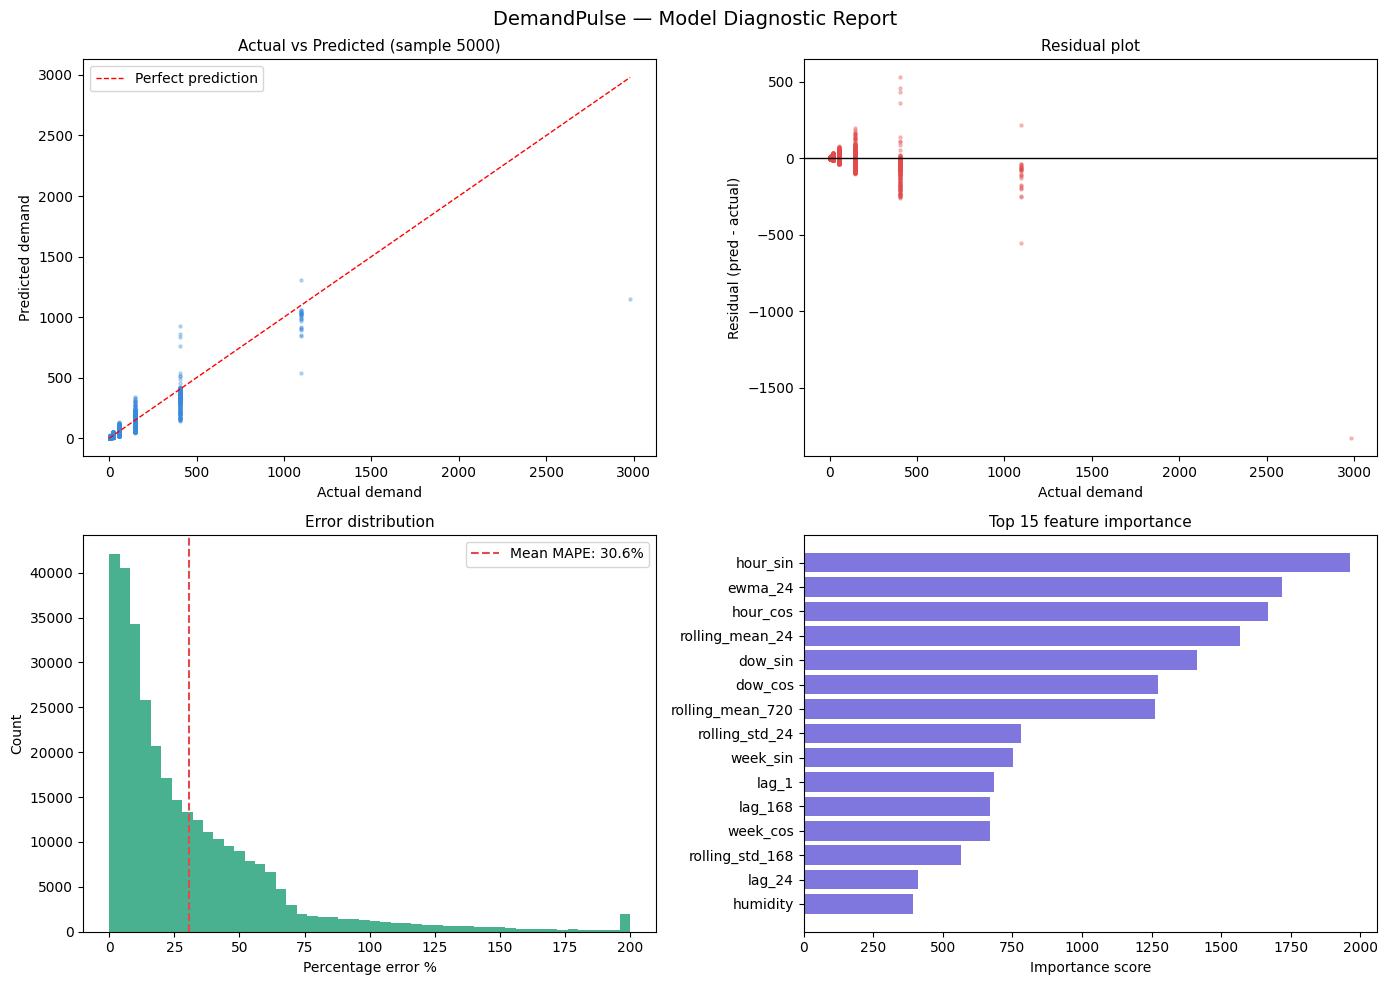

Saved plot_diagnostic_report.png


In [11]:
# ── CHECK 9 — demand distribution plot ───────────────────────────────
print("\n" + "="*60)
print("CHECK 9 — DEMAND DISTRIBUTION PLOTS")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# actual vs predicted scatter
sample_n = min(5000, len(val_df))
sample   = val_df.sample(sample_n, random_state=42)
axes[0,0].scatter(sample['actual'], sample['pred'],
                  alpha=0.3, s=5, color='#378ADD')
max_val = max(sample['actual'].max(), sample['pred'].max())
axes[0,0].plot([0, max_val], [0, max_val],
               'r--', linewidth=1, label='Perfect prediction')
axes[0,0].set_xlabel('Actual demand')
axes[0,0].set_ylabel('Predicted demand')
axes[0,0].set_title('Actual vs Predicted (sample 5000)', fontsize=11)
axes[0,0].legend()

# residual plot
residuals = sample['pred'] - sample['actual']
axes[0,1].scatter(sample['actual'], residuals,
                  alpha=0.3, s=5, color='#E24B4A')
axes[0,1].axhline(y=0, color='black', linewidth=1)
axes[0,1].set_xlabel('Actual demand')
axes[0,1].set_ylabel('Residual (pred - actual)')
axes[0,1].set_title('Residual plot', fontsize=11)

# error distribution
axes[1,0].hist(val_df['pct_err'].dropna().clip(upper=200),
               bins=50, color='#1D9E75',
               edgecolor='none', alpha=0.8)
axes[1,0].axvline(x=mape, color='#E24B4A',
                  linestyle='--', label=f'Mean MAPE: {mape:.1f}%')
axes[1,0].set_xlabel('Percentage error %')
axes[1,0].set_ylabel('Count')
axes[1,0].set_title('Error distribution', fontsize=11)
axes[1,0].legend()

# feature importance top 15
top15 = imp_df.head(15)
axes[1,1].barh(top15['feature'][::-1],
               top15['importance'][::-1],
               color='#7F77DD', edgecolor='none')
axes[1,1].set_title('Top 15 feature importance', fontsize=11)
axes[1,1].set_xlabel('Importance score')

plt.suptitle('DemandPulse — Model Diagnostic Report',
             fontsize=14, fontweight='500')
plt.tight_layout()
plt.savefig('plot_diagnostic_report.png', dpi=150)
plt.show()
print("Saved plot_diagnostic_report.png")

In [12]:
# ── CHECK 10 — hourly prediction pattern ─────────────────────────────
print("\n" + "="*60)
print("CHECK 10 — HOURLY PREDICTION PATTERN")
print("="*60)

hourly = (val_df.groupby('order_hour_of_day')
          .agg(actual=('actual','mean'),
               predicted=('pred','mean'))
          .reset_index())

print(hourly.round(2).to_string(index=False))

peak_actual = hourly.loc[hourly['actual'].idxmax(), 'order_hour_of_day']
peak_pred   = hourly.loc[hourly['predicted'].idxmax(), 'order_hour_of_day']
print(f"\nPeak actual demand hour    : {peak_actual}:00")
print(f"Peak predicted demand hour : {peak_pred}:00")
print(f"{'✓ Peaks match' if peak_actual == peak_pred else '⚠ Peak hours differ — model missing time pattern'}")


CHECK 10 — HOURLY PREDICTION PATTERN
 order_hour_of_day  actual  predicted
                 0   11.66       9.89
                 1    6.39       5.55
                 2    4.24       3.68
                 3    3.50       3.15
                 4    3.57       3.10
                 5    5.44       4.66
                 6   15.71      13.82
                 7   47.85      42.94
                 8   91.47      79.89
                 9  119.41     105.60
                10  130.27     118.27
                11  128.46     116.92
                12  124.49     115.45
                13  126.38     114.57
                14  127.83     115.62
                15  127.78     116.12
                16  123.20     112.60
                17  102.08      90.70
                18   80.82      70.45
                19   62.65      54.97
                20   49.15      43.83
                21   41.90      37.48
                22   33.72      30.59
                23   20.83      18.74

Peak actual

In [13]:
# ── SUMMARY ───────────────────────────────────────────────────────────
print("\n" + "="*60)
print("DIAGNOSTIC SUMMARY")
print("="*60)

issues   = []
good     = []

if missing:
    issues.append(f"Pincode mismatch — {len(missing)} pincodes missing from features_df")
else:
    good.append("Pincode alignment ✓")

if exact > 80:
    issues.append(f"Data leakage — {exact:.1f}% exact match between lag_168 and demand")
else:
    good.append(f"No leakage — {exact:.1f}% coincidental match ✓")

if raw_max < 20:
    good.append(f"Log transform applied ✓ (max demand = {raw_max:.2f})")
else:
    issues.append(f"Log transform NOT applied — max demand = {raw_max:.0f}")

if mape < 30:
    good.append(f"MAPE {mape:.2f}% — within target range ✓")
else:
    issues.append(f"MAPE {mape:.2f}% — above 30% target, consider retuning")

if wape < 15:
    good.append(f"WAPE {wape:.2f}% — excellent ✓")
else:
    issues.append(f"WAPE {wape:.2f}% — above 15% target")

if r2 > 0.85:
    good.append(f"R² {r2:.4f} — strong ✓")
else:
    issues.append(f"R² {r2:.4f} — weak, model underfitting")

if mape < base_mape:
    good.append(f"Model beats baseline by {base_mape - mape:.2f}% MAPE ✓")
else:
    issues.append("Model WORSE than baseline — retrain needed")

print("\n✓ GOOD:")
for g in good:
    print(f"  {g}")

print("\n✗ ISSUES TO FIX:")
if issues:
    for i in issues:
        print(f"  {i}")
else:
    print("  None — everything looks good!")

print("\n" + "="*60)
print("Paste all output above and I will give full analysis")
print("="*60)


DIAGNOSTIC SUMMARY

✓ GOOD:
  Pincode alignment ✓
  No leakage — 38.0% coincidental match ✓
  Log transform applied ✓ (max demand = 8.00)
  R² 0.9005 — strong ✓
  Model beats baseline by 103.33% MAPE ✓

✗ ISSUES TO FIX:
  MAPE 30.58% — above 30% target, consider retuning
  WAPE 20.86% — above 15% target

Paste all output above and I will give full analysis
